In [1]:
# Import pandas, the standard library for data manipulation
import pandas as pd

# Define the URL where our public dataset lives
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Tell pandas to read the CSV file from the URL and store it in a variable called 'dataset'
dataset = pd.read_csv(url)

# Print the first 5 rows of the dataset to verify it loaded correctly
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Display a summary of our dataset, including column names and data types
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# 1. Convert the 'TotalCharges' column from text to numeric. 
# The errors='coerce' part tells pandas to turn any weird blank spaces into official "Missing Values" (NaN).
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

# 2. Drop (delete) any rows that have missing values so our data is perfectly clean.
dataset.dropna(inplace=True)

# 3. Print out the new size of our dataset (Rows, Columns)
print("Data shape after cleaning:", dataset.shape)

Data shape after cleaning: (7032, 21)


Exact Churn Numbers:
Churn
No     5163
Yes    1869
Name: count, dtype: int64




<Axes: title={'center': 'Customer Churn (Yes vs No)'}, xlabel='Churn'>

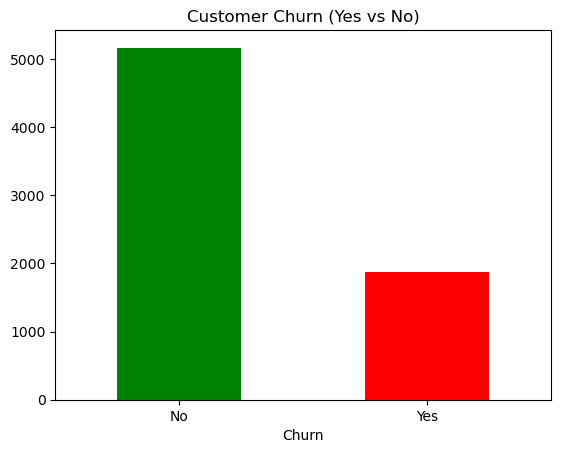

In [4]:
# 1. Count how many customers Churned (Yes) vs Stayed (No)
churn_counts = dataset['Churn'].value_counts()

# Print the exact numbers
print("Exact Churn Numbers:")
print(churn_counts)
print("\n") # This just prints a blank line for readability

# 2. Create a simple bar chart directly from our Pandas data!
churn_counts.plot(kind='bar', title='Customer Churn (Yes vs No)', color=['green', 'red'], rot=0)

In [5]:
# 1. Drop (delete) the customerID column because it doesn't help us predict anything
dataset = dataset.drop('customerID', axis=1)

# 2. Convert all text columns into 1s and 0s using One-Hot Encoding.
# The 'drop_first=True' part ensures we don't make redundant columns (e.g., we only need one column for gender)
dataset_encoded = pd.get_dummies(dataset, drop_first=True, dtype=int)

# 3. Display the first 5 rows of our new, 100% numeric dataset!
dataset_encoded.head()

# Tell Pandas to show all columns without hiding any behind '...'
pd.set_option('display.max_columns', None)

# Show the first 5 rows again
dataset_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1


In [6]:
# Import the tool that splits our data
from sklearn.model_selection import train_test_split

# 1. Define our Target (y) - this is the answer we want to predict
y = dataset_encoded['Churn_Yes']

# 2. Define our Features (X) - these are all the clues (drop the answer column)
X = dataset_encoded.drop('Churn_Yes', axis=1)

# 3. Split the data! 
# test_size=0.2 means 80% is for training, 20% is hidden for the Final Exam.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print a success message
print(f"Success! We have {X_train.shape[0]} customers to train the model.")
print(f"We have {X_test.shape[0]} customers hidden for the final test.")

Success! We have 5625 customers to train the model.
We have 1407 customers hidden for the final test.


In [14]:
# Import the Random Forest algorithm from Scikit-Learn
from sklearn.ensemble import RandomForestClassifier

# 1. Create the model (the "brain"). 
# random_state=42 just ensures we get the same consistent results every time we run it.
model = RandomForestClassifier(random_state=42)

# 2. Train the model! 
# The .fit() command tells the model to look at the clues (X_train) and the answers (y_train) and learn the patterns.
model.fit(X_train, y_train)

# Print a success message
print("Model training complete! Your Random Forest is now officially trained.")

Model training complete! Your Random Forest is now officially trained.


In [16]:
# Import our grading tools
from sklearn.metrics import accuracy_score, classification_report

# 1. Ask the model to take the Final Exam. 
# The .predict() command is incredibly fast because the heavy training is already done!
predictions = model.predict(X_test)

# 2. Grade the exam: Compare the model's predictions to the actual answers
accuracy = accuracy_score(y_test, predictions)

# 3. Print the final grade!
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:\n")
print(classification_report(y_test, predictions))

Model Accuracy: 78.54%

Detailed Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [18]:
# 1. Create the Upgraded Model with our new rules
model_v2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# 2. Train it!
model_v2.fit(X_train, y_train)

# 3. Take the Final Exam again
predictions_v2 = model_v2.predict(X_test)

# 4. Print the new grades
from sklearn.metrics import accuracy_score, classification_report
print(f"Upgraded Model Accuracy: {accuracy_score(y_test, predictions_v2) * 100:.2f}%")
print("\nDetailed Report:\n")
print(classification_report(y_test, predictions_v2))

Upgraded Model Accuracy: 79.10%

Detailed Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Top 5 Reasons Customers Churn:
                        Feature  Importance
1                        tenure    0.181404
3                  TotalCharges    0.160981
2                MonthlyCharges    0.125859
10  InternetService_Fiber optic    0.067072
25            Contract_Two year    0.059209




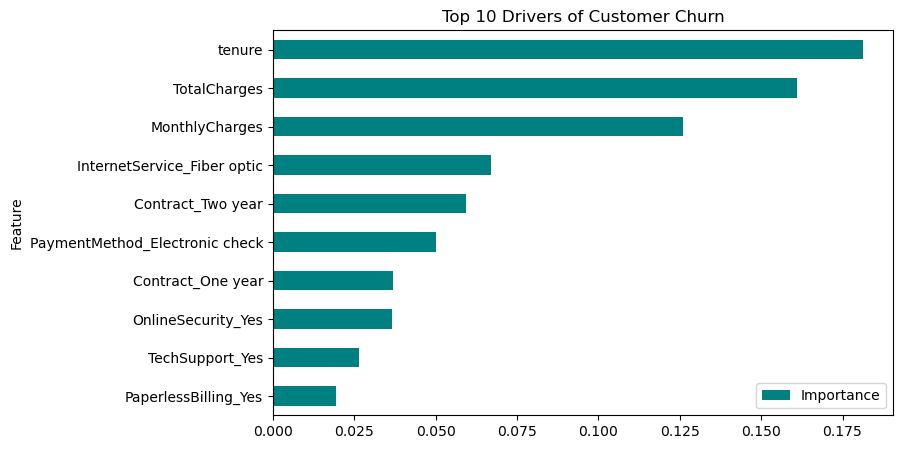

In [20]:
# Import our plotting tool
import matplotlib.pyplot as plt

# 1. Extract the "Feature Importances" from our upgraded model
importances = model_v2.feature_importances_

# 2. Create a neat Pandas table combining the column names with their importance scores
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# 3. Sort the table so the biggest reasons are at the top
feature_ranking = feature_ranking.sort_values(by='Importance', ascending=False)

# 4. Print the Top 5 reasons to the screen
print("Top 5 Reasons Customers Churn:")
print(feature_ranking.head(5))
print("\n")

# 5. Draw a beautiful horizontal bar chart for the Top 10 reasons
feature_ranking.head(10).plot(kind='barh', x='Feature', y='Importance', color='teal', figsize=(8, 5), title='Top 10 Drivers of Customer Churn')
plt.gca().invert_yaxis() # This flips the chart so the #1 reason is at the very top
plt.show() # Display the chart